In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
import sklearn
from sklearn import metrics
import os
import pandas as pd
import time
from sklearn.manifold import TSNE
import logging
logging.disable(30)
from collections import  Counter
import random
random_seed =3407
import math
from fitter import Fitter
from scipy.linalg import det, inv
random.seed(random_seed )  # set random seed for python
np.random.seed(random_seed )  # set random seed for numpy
tf.random.set_seed(random_seed )  # set random seed for tensorflow-cpu
os.environ['TF_DETERMINISTIC_OPS'] = '1' # set random seed for tensorflow-gpu

In [2]:
data1 =pd.read_csv(r"F:\数据集样本划分\齿轮数据\DDS试验台--测点 工况\变负载齿轮数据集-3072\data_load0.csv").values
label1=pd.read_csv(r"F:\数据集样本划分\齿轮数据\DDS试验台--测点 工况\变负载齿轮数据集-3072\label_load0.csv").values

data2 =pd.read_csv(r"F:\数据集样本划分\齿轮数据\DDS试验台--测点 工况\变负载齿轮数据集-3072\data_load1.csv").values
label2=pd.read_csv(r"F:\数据集样本划分\齿轮数据\DDS试验台--测点 工况\变负载齿轮数据集-3072\label_load1.csv").values

data3 =pd.read_csv(r"F:\数据集样本划分\齿轮数据\DDS试验台--测点 工况\变负载齿轮数据集-3072\data_load2.csv").values
label3=pd.read_csv(r"F:\数据集样本划分\齿轮数据\DDS试验台--测点 工况\变负载齿轮数据集-3072\label_load2.csv").values

data4 =pd.read_csv(r"F:\数据集样本划分\齿轮数据\DDS试验台--测点 工况\变负载齿轮数据集-3072\data_load3.csv").values
label4=pd.read_csv(r"F:\数据集样本划分\齿轮数据\DDS试验台--测点 工况\变负载齿轮数据集-3072\label_load3.csv").values

source_data = data1
source_label= label1
target_data = data4
target_label= label4

name=r"L1--L4"

source_data.shape,source_label.shape,target_data.shape,target_label.shape

((5000, 3072), (5000, 5), (5000, 3072), (5000, 5))

In [3]:
batch=512
def normalized_preprocess (data):
    data=(data-data.min(axis=1).reshape((len(data),1)))/(data.max(axis=1).reshape((len(data),1))-data.min(axis=1).reshape((len(data),1)))
    return data
source_data=normalized_preprocess(source_data)
target_data=normalized_preprocess(target_data)

source_data=tf.expand_dims(source_data,axis=-1)
target_data=tf.expand_dims(target_data,axis=-1)

train_dataset=tf.data.Dataset.from_tensor_slices((source_data,target_data,source_label,target_label))
train_dataset=train_dataset.shuffle(40000).batch(batch,drop_remainder=True)

test_dataset=tf.data.Dataset.from_tensor_slices((source_data,target_data,source_label,target_label))
test_dataset=test_dataset.batch(source_data.shape[0])

In [4]:
def Model():
    input_1=tf.keras.Input(shape=(3072,1),name='source_data')

    x=tf.keras.layers.Conv1D(filters=16,kernel_size=64,strides=16,activation='relu',padding='same',name='conv1')(input_1)
    x=tf.keras.layers.BatchNormalization(name='bn1')(x)
    x=tf.keras.layers.MaxPooling1D(pool_size=2,strides=2,padding='same',name='plool1')(x)

    x=tf.keras.layers.Conv1D(filters=64,kernel_size=3,strides=1,activation='relu',padding='same',name='conv2')(x)
    x=tf.keras.layers.BatchNormalization(name='bn2')(x)
    x=tf.keras.layers.MaxPooling1D(pool_size=2,strides=2,padding='same',name='plool2')(x)

    x=tf.keras.layers.Conv1D(filters=128,kernel_size=3,strides=1,activation='relu',padding='same',name='conv3')(x)
    x=tf.keras.layers.BatchNormalization(name='bn3')(x)
    x=tf.keras.layers.MaxPooling1D(pool_size=2,strides=2,padding='same',name='plool3')(x)

    x=tf.keras.layers.Conv1D(filters=256,kernel_size=3,strides=1,activation='relu',padding='same',name='conv5')(x)
    x=tf.keras.layers.BatchNormalization(name='bn5')(x)
    x=tf.keras.layers.MaxPooling1D(pool_size=2,strides=2,padding='same',name='plool5')(x)

    x=tf.keras.layers.GlobalAveragePooling1D()(x)

    y1=tf.keras.layers.Dense(128,activation='relu',name='cl_1')(x)
    y2=tf.keras.layers.Dense(5,name='cl_2')(y1)

    model=tf.keras.Model(inputs=input_1,outputs=[y1,y2])
    
    return model

model=Model()
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
source_data (InputLayer)     [(None, 3072, 1)]         0         
_________________________________________________________________
conv1 (Conv1D)               (None, 192, 16)           1040      
_________________________________________________________________
bn1 (BatchNormalization)     (None, 192, 16)           64        
_________________________________________________________________
plool1 (MaxPooling1D)        (None, 96, 16)            0         
_________________________________________________________________
conv2 (Conv1D)               (None, 96, 64)            3136      
_________________________________________________________________
bn2 (BatchNormalization)     (None, 96, 64)            256       
_________________________________________________________________
plool2 (MaxPooling1D)        (None, 48, 64)            0     

In [5]:
def rbf_metric(X, Y, sigmas=(1,), wts=None, biased=True):
    K_XX, K_XY, K_YY, d = rbf_kernel(X, Y, sigmas, wts)
    return _metric(K_XX, K_XY, K_YY, const_diagonal=d, biased=biased)


def rbf_kernel(X, Y, sigmas, wts=None):
    if wts is None:
        wts = [1] * len(sigmas)

    XX = tf.matmul(X, X, transpose_b=True)
    XY = tf.matmul(X, Y, transpose_b=True)
    YY = tf.matmul(Y, Y, transpose_b=True)

    X_sqnorms = tf.linalg.diag_part(XX)
    Y_sqnorms = tf.linalg.diag_part(YY)

    r = lambda x: tf.expand_dims(x, 0)
    c = lambda x: tf.expand_dims(x, 1)

    K_XX, K_XY, K_YY = 0, 0, 0
    for sigma, wt in zip(sigmas, wts):
        gamma = 1 / (2 * sigma**2)
        K_XX += wt * tf.exp(-gamma * (-2 * XX + c(X_sqnorms) + r(X_sqnorms)))
        K_XY += wt * tf.exp(-gamma * (-2 * XY + c(X_sqnorms) + r(Y_sqnorms)))
        K_YY += wt * tf.exp(-gamma * (-2 * YY + c(Y_sqnorms) + r(Y_sqnorms)))
    return K_XX, K_XY, K_YY, tf.reduce_sum(wts)
    

def _metric(K_XX, K_XY, K_YY, const_diagonal=False, biased=False):
    ns = tf.cast(K_XX.get_shape()[0], tf.float32)
    nt = tf.cast(K_YY.get_shape()[0], tf.float32)
    
    C_K_XX=tf.pow(K_XX,2)
    C_K_YY=tf.pow(K_YY,2)
    C_K_XY=tf.pow(K_XY,2)


    if biased:
        metric = (tf.reduce_sum(C_K_XX) / (ns * ns)
              + tf.reduce_sum(C_K_YY) / (nt * nt)
              - 2 * tf.reduce_sum(C_K_XY) / (ns * nt))
    else:
        if const_diagonal is not False:
            trace_X = ns * const_diagonal
            trace_Y = nt * const_diagonal
        else:
            trace_X = tf.linalg.trace(C_K_XX)
            trace_Y = tf.linalg.trace(C_K_YY)

        metric = ((tf.reduce_sum(C_K_XX) - trace_X) / ((ns-1) * ns)
              + (tf.reduce_sum(C_K_YY) - trace_Y) / ((nt-1) * nt)
              - 2 * tf.reduce_sum(C_K_XY) / (ns * nt))
    return metric


def HoSDR(X1,X2,m=2, bandwidths=[5]):
    kernel_loss = rbf_metric(10**(2*m)*tf.pow(X1,2*m),10**(2*m)*tf.pow(X2,2*m), sigmas=bandwidths)
    return 100*kernel_loss

In [6]:
def DOA(mu1, sigma1, mu2, sigma2):
    mu1, sigma1, mu2, sigma2=mu1.numpy(), sigma1.numpy(), mu2.numpy(), sigma2.numpy()
    sigma = (sigma1 + sigma2) / 2.
    inv_sigma = inv(sigma)
    diff = mu1 - mu2
    mahalanobis = diff.T @ inv_sigma @ diff
    det_sigma = det(sigma)
    det_sigma1 = det(sigma1)
    det_sigma2 = det(sigma2)
    dof = np.exp(-0.125 * mahalanobis) * np.sqrt(det_sigma / np.sqrt(det_sigma1 * det_sigma2))
    return dof

def tf_cov(x):
    mean_x = tf.reduce_mean(x, axis=0)
    cov_xx = tf.matmul(tf.transpose(x-mean_x), x-mean_x)/tf.cast(tf.shape(x)[0], tf.float32)
    return mean_x,cov_xx

def classification_division(data,label):
    label=tf.argmax(label,axis=-1)
    N=data.shape[0]
    a,b,c,d,e=[],[],[],[],[]
    for i in range (N):
        if  label[i]==0:
            a.append(data[i])
        elif label[i]==1:
            b.append(data[i])
        elif label[i]==2:
            c.append(data[i])
        elif label[i]==3:
            d.append(data[i])
        elif label[i]==4:
            e.append(data[i])
    a=np.array(a)
    b=np.array(b)
    c=np.array(c)
    d=np.array(d)
    e=np.array(e)
    return a,b,c,d,e

def Class_loss(index,s,t_set,thre,mult):
    loss=0
    doa_set=[]
    if s.shape[0]!=0 and t_set[index].shape[0]!=0 and t_set[index].shape[0]>(s.shape[0]/mult):
        mu_s,sigma_s=tf_cov(s)
        mu_ind,sigma_ind=tf_cov(t_set[index])
        doa_ind = DOA(mu_ind, sigma_ind, mu_s, sigma_s)
        
        for ti in t_set:
            if s.shape[0]!=0 and ti.shape[0]!=0 and ti.shape[0]>(s.shape[0]/mult): #mult:To maintain a sufficient number of samples to ensure that the distribution pattern solved for is representative.
                mu_s,sigma_s=tf_cov(s)
                mu_ti,sigma_ti=tf_cov(ti)
                doa = DOA(mu_ti, sigma_ti, mu_s, sigma_s)
                doa_set.append(doa)
        #print('SET:',index,doa_set)
        
        if doa_ind>thre and doa_ind==max(doa_set):
            loss = doa*HoSDR(s,t_set[index])
        #print('KKK:',index,loss)
    return loss

def AJDA(data1,label1,data2,label2,thre,mult):
    s1,s2,s3,s4,s5=classification_division(data1,label1)
    t1,t2,t3,t4,t5=classification_division(data2,label2)
    
    MDA_loss=10*HoSDR(data1,data2)
    
    CDA_1=Class_loss(0,s1,[t1,t2,t3,t4,t5],thre,mult)
    CDA_2=Class_loss(1,s2,[t1,t2,t3,t4,t5],thre,mult)
    CDA_3=Class_loss(2,s3,[t1,t2,t3,t4,t5],thre,mult)
    CDA_4=Class_loss(3,s4,[t1,t2,t3,t4,t5],thre,mult)
    CDA_5=Class_loss(4,s5,[t1,t2,t3,t4,t5],thre,mult)
    #print('LOSS:',MDA_loss,CDA_1,CDA_2,CDA_3,CDA_4,CDA_5)
    
    CDA_loss=CDA_1+CDA_2+CDA_3+CDA_4+CDA_5
    AJDA_loss=MDA_loss+CDA_loss
    
    return MDA_loss, CDA_loss, AJDA_loss

In [7]:
clc_loss=tf.keras.metrics.Mean('clc_loss')                                      #使用metrics创建评价指标
jda_loss=tf.keras.metrics.Mean('ajda_loss')
pre_train_loss=tf.keras.metrics.Mean("pre_train_loss")

train_accuracy=tf.keras.metrics.CategoricalAccuracy('train_accuracy')
pre_train_accuracy=tf.keras.metrics.CategoricalAccuracy('pre_train_accuracy')
test_accuracy=tf.keras.metrics.CategoricalAccuracy('test_accuracy')

train_acc=[]
test_acc=[]
clc_loss_=[]
jda_loss_=[]

In [8]:
pre_optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
loss_func=tf.keras.losses.CategoricalCrossentropy(from_logits=True)

In [9]:
#batch training
def train_step(model, source_data,target_data,source_label,target_label):
    u=1
    with tf.GradientTape() as t:
        out1,output1 = model(source_data,training = True)                                
        out2,output2 = model(target_data,training = True)  
        pseudo_label= tf.one_hot(tf.argmax(output2,axis=-1),depth=target_label.shape[-1])
        
        mda_loss, cda_loss, ajda_loss=AJDA(output1,source_label,output2,pseudo_label,thre=0.9,mult=1.5)
        ajda_loss=HoSDR(output1,output2)
        loss_step =loss_func(source_label,output1)+u*ajda_loss       
    
    grads = t.gradient(loss_step, model.trainable_variables)
    
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    
    jda_loss(u*ajda_loss)
    clc_loss(loss_func(source_label,output1))
    train_accuracy(source_label,output1)
    test_accuracy(target_label,output2)

    
def train():
    for epoch in range(300):
        for (batch, (source_data,target_data,source_label,target_label)) in enumerate(train_dataset):
            train_step(model,source_data,target_data,source_label,target_label)
        train_acc.append(train_accuracy.result())
        jda_loss_.append(jda_loss.result())
        clc_loss_.append(clc_loss.result())
        test_acc.append(test_accuracy.result())
        
        print('Epoch{}, ajda_loss is {:.5f}, clc_loss is {:.5f}, train_accuracy is {:.5f},test_accuracy is {:.5f}'.format(epoch+1,
                                                                                          jda_loss.result(),
                                                                                          clc_loss.result(),           
                                                                                          train_accuracy.result(),
                                                                                          test_accuracy.result(),
                                                                                                      ))
        
        jda_loss.reset_states()
        clc_loss.reset_states()
        train_accuracy.reset_states()
        test_accuracy.reset_states()

In [10]:
train()

Epoch1, ajda_loss is 0.42038, clc_loss is 1.58947, train_accuracy is 0.28103,test_accuracy is 0.24371
Epoch2, ajda_loss is 0.18222, clc_loss is 1.45860, train_accuracy is 0.37413,test_accuracy is 0.28342
Epoch3, ajda_loss is 0.25351, clc_loss is 1.38520, train_accuracy is 0.43750,test_accuracy is 0.31337
Epoch4, ajda_loss is 0.19046, clc_loss is 1.33503, train_accuracy is 0.46159,test_accuracy is 0.31293
Epoch5, ajda_loss is 0.16390, clc_loss is 1.30322, train_accuracy is 0.48937,test_accuracy is 0.35460
Epoch6, ajda_loss is 0.17227, clc_loss is 1.26340, train_accuracy is 0.52018,test_accuracy is 0.37717
Epoch7, ajda_loss is 0.20614, clc_loss is 1.21111, train_accuracy is 0.53385,test_accuracy is 0.38346
Epoch8, ajda_loss is 0.21243, clc_loss is 1.18164, train_accuracy is 0.56944,test_accuracy is 0.41254
Epoch9, ajda_loss is 0.19642, clc_loss is 1.20229, train_accuracy is 0.57639,test_accuracy is 0.43902
Epoch10, ajda_loss is 0.15190, clc_loss is 1.19485, train_accuracy is 0.56923,test

Epoch81, ajda_loss is 0.25621, clc_loss is 0.54419, train_accuracy is 0.91146,test_accuracy is 0.75043
Epoch82, ajda_loss is 0.22487, clc_loss is 0.57125, train_accuracy is 0.90994,test_accuracy is 0.74935
Epoch83, ajda_loss is 0.17701, clc_loss is 0.59311, train_accuracy is 0.92339,test_accuracy is 0.76953
Epoch84, ajda_loss is 0.16459, clc_loss is 0.60231, train_accuracy is 0.91493,test_accuracy is 0.75673
Epoch85, ajda_loss is 0.17846, clc_loss is 0.56753, train_accuracy is 0.92318,test_accuracy is 0.77756
Epoch86, ajda_loss is 0.17989, clc_loss is 0.54095, train_accuracy is 0.93338,test_accuracy is 0.77431
Epoch87, ajda_loss is 0.17095, clc_loss is 0.52476, train_accuracy is 0.93620,test_accuracy is 0.76801
Epoch88, ajda_loss is 0.13628, clc_loss is 0.52635, train_accuracy is 0.93186,test_accuracy is 0.77734
Epoch89, ajda_loss is 0.21341, clc_loss is 0.48878, train_accuracy is 0.93012,test_accuracy is 0.78190
Epoch90, ajda_loss is 0.21255, clc_loss is 0.49786, train_accuracy is 0.9

Epoch160, ajda_loss is 0.22675, clc_loss is 0.31201, train_accuracy is 0.98763,test_accuracy is 0.90017
Epoch161, ajda_loss is 0.14593, clc_loss is 0.34087, train_accuracy is 0.98394,test_accuracy is 0.89193
Epoch162, ajda_loss is 0.15577, clc_loss is 0.33635, train_accuracy is 0.98025,test_accuracy is 0.88628
Epoch163, ajda_loss is 0.14683, clc_loss is 0.31442, train_accuracy is 0.98220,test_accuracy is 0.88672
Epoch164, ajda_loss is 0.15178, clc_loss is 0.29947, train_accuracy is 0.98806,test_accuracy is 0.89540
Epoch165, ajda_loss is 0.18856, clc_loss is 0.28424, train_accuracy is 0.98720,test_accuracy is 0.90082
Epoch166, ajda_loss is 0.20615, clc_loss is 0.29003, train_accuracy is 0.98698,test_accuracy is 0.90603
Epoch167, ajda_loss is 0.15023, clc_loss is 0.30755, train_accuracy is 0.98481,test_accuracy is 0.90538
Epoch168, ajda_loss is 0.19005, clc_loss is 0.29603, train_accuracy is 0.99175,test_accuracy is 0.91211
Epoch169, ajda_loss is 0.15791, clc_loss is 0.28362, train_accur

Epoch239, ajda_loss is 0.13259, clc_loss is 0.20631, train_accuracy is 0.99653,test_accuracy is 0.94965
Epoch240, ajda_loss is 0.15564, clc_loss is 0.20108, train_accuracy is 0.99696,test_accuracy is 0.95530
Epoch241, ajda_loss is 0.11734, clc_loss is 0.19643, train_accuracy is 0.99718,test_accuracy is 0.95551
Epoch242, ajda_loss is 0.10412, clc_loss is 0.17724, train_accuracy is 0.99696,test_accuracy is 0.95898
Epoch243, ajda_loss is 0.11715, clc_loss is 0.17181, train_accuracy is 0.99718,test_accuracy is 0.95833
Epoch244, ajda_loss is 0.16860, clc_loss is 0.17006, train_accuracy is 0.99848,test_accuracy is 0.95985
Epoch245, ajda_loss is 0.17993, clc_loss is 0.18987, train_accuracy is 0.99848,test_accuracy is 0.95660
Epoch246, ajda_loss is 0.09427, clc_loss is 0.19996, train_accuracy is 0.99783,test_accuracy is 0.95616
Epoch247, ajda_loss is 0.10594, clc_loss is 0.17357, train_accuracy is 0.99718,test_accuracy is 0.95508
Epoch248, ajda_loss is 0.17119, clc_loss is 0.15944, train_accur

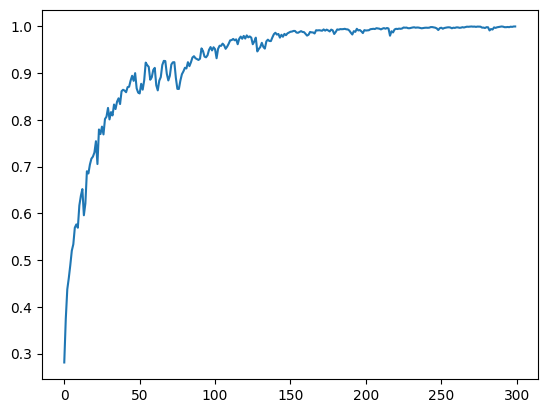

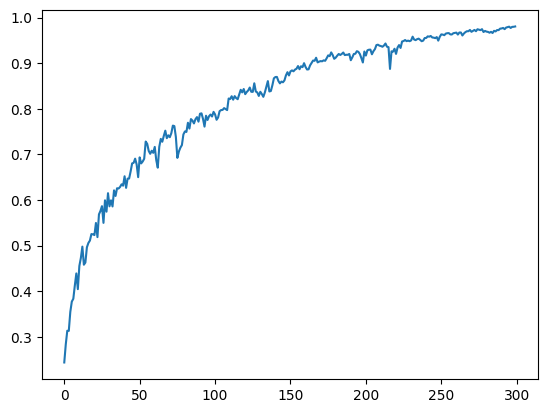

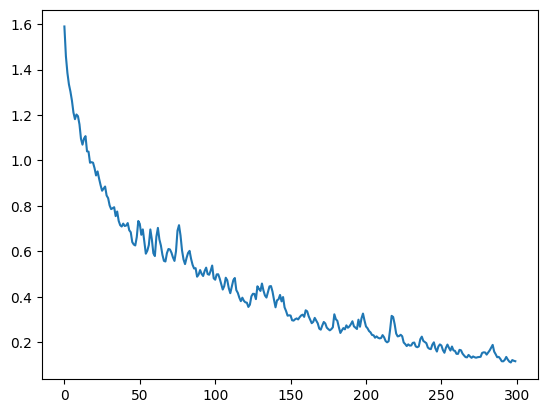

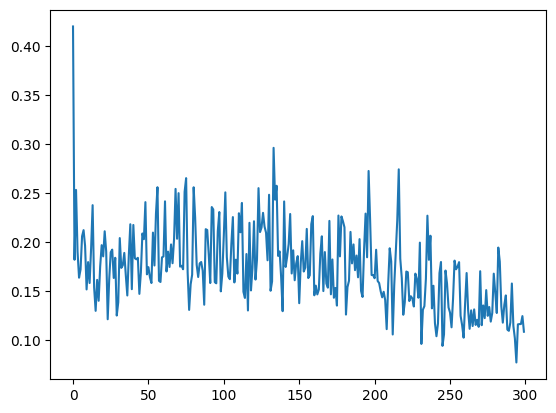

In [11]:
string=[train_acc,test_acc ,clc_loss_,jda_loss_]
for i in string:
    plt.plot(i)
    plt.show()